In [3]:
import numpy as np

In [6]:
data=np.load("Data\extend_mnist_eval.npz")

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Abhinav\AppData\Local\Temp\ipykernel_23024\1823914149.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  data=np.load("Data\extend_mnist_eval.npz")


In [7]:
print(data.files)

['img', 'label']


In [18]:
x=data["img"]
y=data["label"]
print("X shape :: ", x.shape)
print("Y shape :: ", y.shape)
print("X datatype :: ", x.dtype)
print("Y datatype :: ", y.dtype)
print("X min :: ", x.min())
print("Y min :: ", y.min())
print("X max :: ", x.max())
print("Y max :: ", y.max())
print("First label:", y[0])


X shape ::  (15086, 28, 28)
Y shape ::  (15086,)
X datatype ::  float32
Y datatype ::  float32
X min ::  0.0
Y min ::  0.0
X max ::  255.0
Y max ::  15.0
First label: 12.0


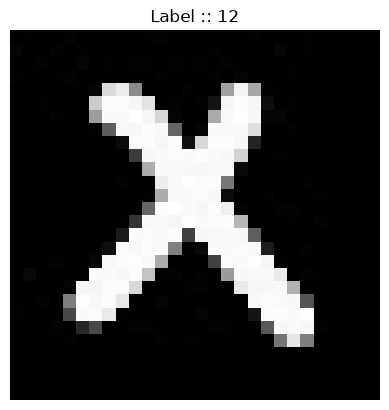

In [13]:
import matplotlib.pyplot as plt

plt.imshow(x[0], cmap="gray")
plt.title(f"Label :: {int(y[0])}")
plt.axis("off")
plt.show()

In [19]:
x=x/255.0
print(x.min())
print(x.max())

0.0
1.0


In [21]:
x=x.reshape(x.shape[0],-1)

In [22]:
x.shape

(15086, 784)

In [23]:
y=y.astype(int)

In [24]:
print(y.dtype)

int64


In [25]:
print(np.unique(y))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [26]:
classes,count=np.unique(y, return_counts=True)
for c,count in zip(classes, count):
    print(c, count)


0 980
1 1135
2 1032
3 1010
4 982
5 892
6 958
7 1028
8 974
9 1009
10 759
11 975
12 766
13 636
14 975
15 975


Working for Input Neurons

In [42]:
ineurons=128
w1=np.random.randn(x.shape[1], ineurons)
b1=np.zeros((1, ineurons))

Working for Output Neurons

In [43]:
oneurons=16
w2=np.random.randn(ineurons, oneurons)
b2=np.zeros((1, oneurons))

In [44]:
print(w1.shape)
print(b1.shape)
print(w2.shape)
print(b2.shape)

(784, 128)
(1, 128)
(128, 16)
(1, 16)


Calculating Hidden Layers of the Neural Network

In [45]:
z1=np.dot(x,w1)+b1

In [46]:
print(z1.shape)

(15086, 128)


In [47]:
def relu(x):
    return np.maximum(0,x)

In [48]:
A1 = relu(z1)
A1.shape

(15086, 128)

FROM HIDDEN LAYER TO OUTPUT LAYER

In [49]:
z2=np.dot(A1, w2)+b2


In [50]:
def softmax(x):
    exp_x=np.exp(x)
    return exp_x/np.sum(exp_x, axis=1, keepdims=True)

In [51]:
A2=softmax(z2)

In [52]:
print(A2.shape)

(15086, 16)


In [53]:
print(A2[0])

[2.89478017e-091 5.54794560e-125 2.60306792e-081 7.79891327e-015
 6.45574175e-092 1.58175864e-074 1.00000000e+000 1.55579277e-031
 1.12174333e-090 1.91719648e-088 1.92582992e-044 1.32799053e-112
 3.06902019e-022 2.24241743e-032 2.59016678e-119 4.97742700e-087]


In [54]:
np.argmax(A2[0])

np.int64(6)

In [ ]:
prediction = np.argmax(A2[0])
correct_prediction=y[0]
print("Prediction:", prediction)
print("Actual:", y[0])

Prediction: 6
Actual: 12


In [59]:
correct_class = y[0]
correct_probability = A2[0, correct_class]

epsilon = 1e-8
loss = -np.log(correct_probability + epsilon)

print("Actual class:", correct_class)
print("Probability:", correct_probability)
print("Loss:", loss)

Actual class: 12
Probability: 3.069020185782057e-22
Loss: 18.420680743952335


In [60]:
indices = np.arange(len(y))
correct_probabilities = A2[indices, y]
epsilon = 1e-8
losses = -np.log(correct_probabilities + epsilon)
loss = np.mean(losses)
print("Loss:", loss)

Loss: 17.306128422178514
